In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#Load Dataset
df = pd.read_csv(r"C:\Users\inter\Desktop\Shrutika\Python-Practical\ML Project 3 Heart Disease Prediction\heart.csv")
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [20]:
#Data Cleaning
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

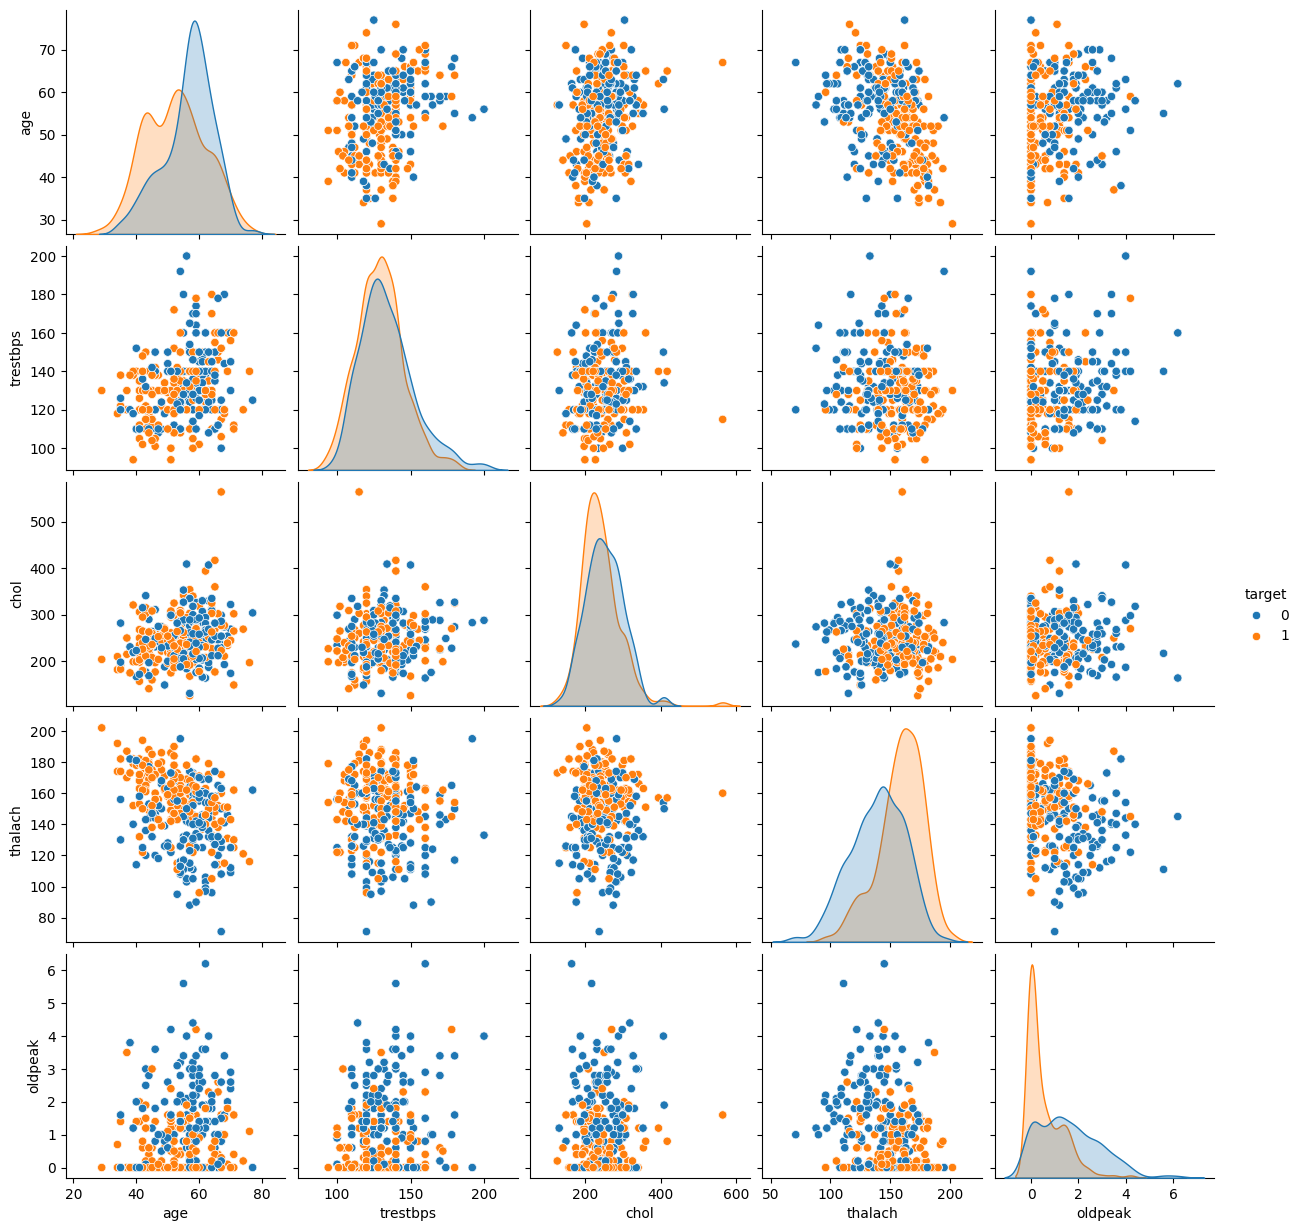

In [4]:
#Pairplot
sns.pairplot(df[['age','trestbps','chol','thalach','oldpeak','target']],hue='target')
plt.show()

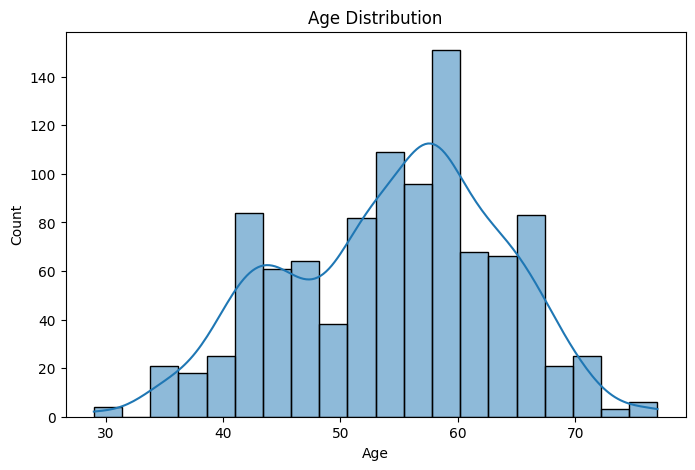

In [5]:
#Histplot
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

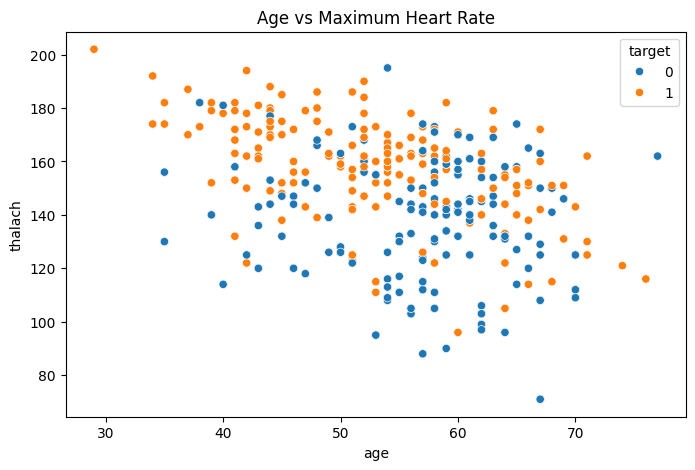

In [6]:
#Scatterplot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='age',y='thalach',hue='target')
plt.title("Age vs Maximum Heart Rate")
plt.show()

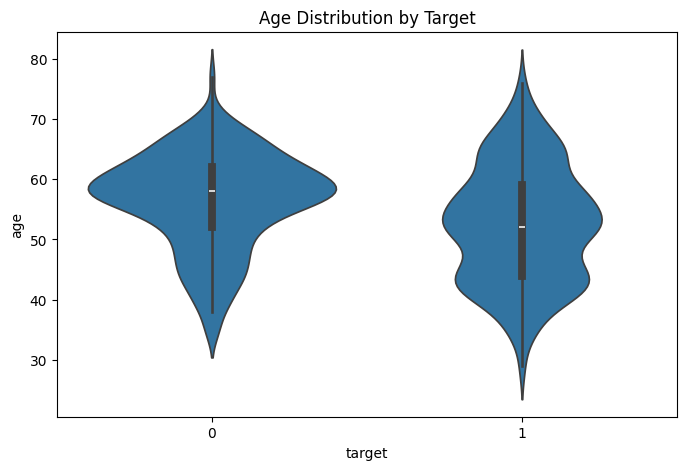

In [8]:
#Violinplot
plt.figure(figsize=(8,5))
sns.violinplot(data=df,x='target',y='age')
plt.title("Age Distribution by Target")
plt.show()

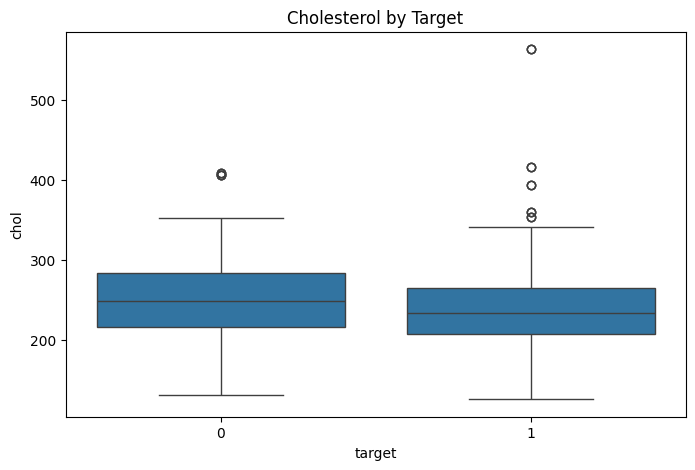

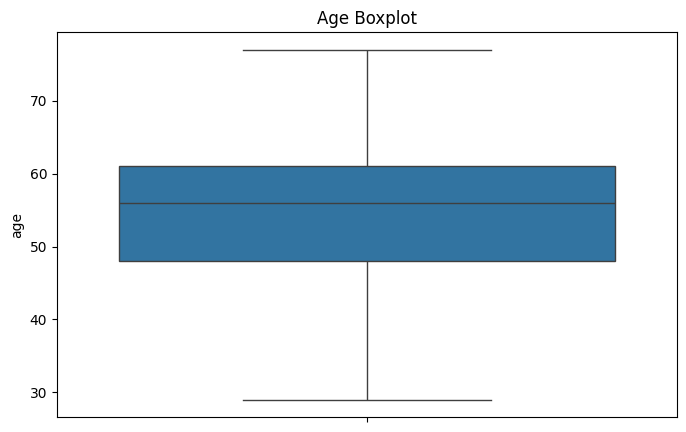

In [9]:
#Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='target', y='chol')
plt.title("Cholesterol by Target")
plt.show()

#Boxplot for Age
plt.figure(figsize=(8,5))
sns.boxplot(data=df,y='age')
plt.title("Age Boxplot")
plt.show()

In [10]:
#Data Split
X = df.drop("target", axis=1)
y = df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
#Logistic Regression
lr = LogisticRegression() #initalize logistic regression
lr.fit(X_train, y_train) #train the model
y_pred_log = lr.predict(X_test) #predict model by using test

#Model Evalution
accuracy_lr = accuracy_score(y_test,y_pred_log)
conf_matrix_lr = confusion_matrix(y_test, y_pred_log)
class_report_lr = classification_report(y_test, y_pred_log)

#print evalution model
print(f"Logistic Regression Accuracy: {accuracy_lr:2f}")
print("Confusion Matrix:")
print(conf_matrix_lr)
print("Classification Report:")
print(class_report_lr)

Logistic Regression Accuracy: 0.809756
Confusion Matrix:
[[70 30]
 [ 9 96]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



In [13]:
#Decision Tree
dt = DecisionTreeClassifier() #initalize decision tree
dt.fit(X_train, y_train) #train the model
y_pred_log = dt.predict(X_test) #predict model by using test

#Model Evalution
accuracy_dt = accuracy_score(y_test,y_pred_log)
conf_matrix_dt = confusion_matrix(y_test, y_pred_log)
class_report_dt = classification_report(y_test, y_pred_log)

#print evalution model
print(f"Decision Tree Accuracy: {accuracy_dt:2f}")
print("Confusion Matrix:")
print(conf_matrix_dt)
print("Classification Report:")
print(class_report_dt)

Decision Tree Accuracy: 0.985366
Confusion Matrix:
[[100   0]
 [  3 102]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [14]:
#Knearestneighbors
knn = KNeighborsClassifier() #initalize knn
knn.fit(X_train, y_train) #train the model
y_pred_log = knn.predict(X_test) #predict model by using test

#Model Evalution
accuracy_knn = accuracy_score(y_test,y_pred_log)
conf_matrix_knn = confusion_matrix(y_test, y_pred_log)
class_report_knn = classification_report(y_test, y_pred_log)

#print evalution model
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:2f}")
print("Confusion Matrix:")
print(conf_matrix_knn)
print("Classification Report:")
print(class_report_knn)

K-Nearest Neighbors Accuracy: 0.863415
Confusion Matrix:
[[87 13]
 [15 90]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       100
           1       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



Text(1180.4281045751634, 0.5, 'Actual')

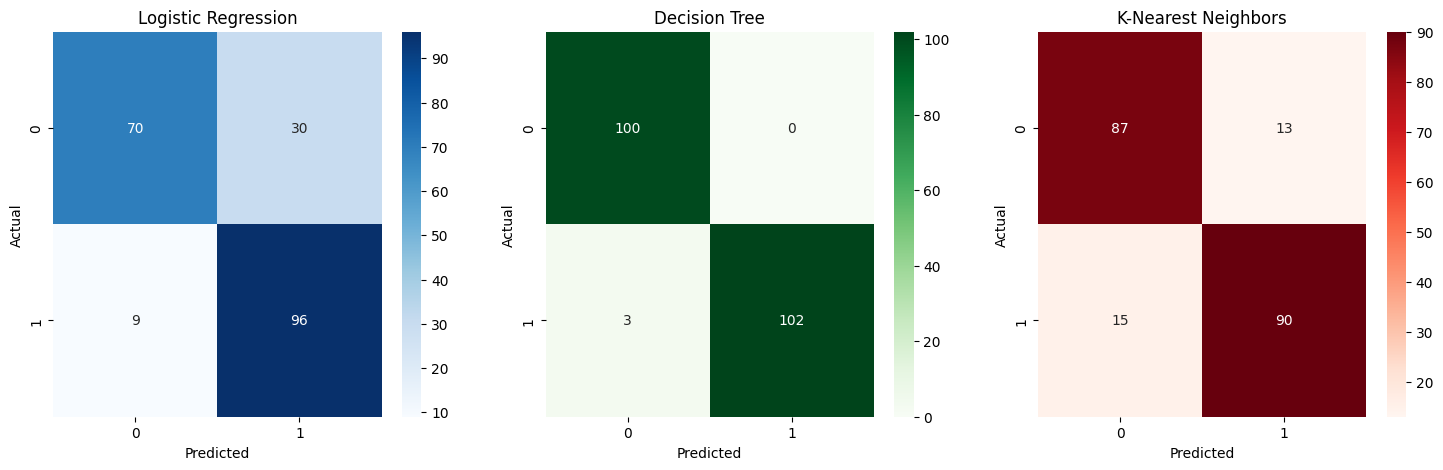

In [15]:
#Visualizing Confusion Metrices
fig, axes = plt.subplots(1,3,figsize=(18,5))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title("K-Nearest Neighbors")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

In [16]:
#Pickle File

import pickle

# Save trained Logistic Regression model
with open('heart_model.pkl', 'wb') as model_file:
    pickle.dump(dt, model_file)

# Save StandardScaler
with open('heart_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [19]:
#Inferencing Function
import pickle
import pandas as pd

# Load the trained model and scaler
def load_model_and_scaler(model_filename='heart_model.pkl',
                          scaler_filename='heart_scaler.pkl'):
    """Loads the trained model and scaler from pickle files."""

    # Load trained model
    with open(r'C:\Users\inter\Desktop\Shrutika\Python-Practical\ML Project 3 Heart Disease Prediction\heart_model.pkl', 'rb') as model_file:
        model = pickle.load(model_file)

    # Load scaler
    with open(r'C:\Users\inter\Desktop\Shrutika\Python-Practical\ML Project 3 Heart Disease Prediction\heart_scaler.pkl', 'rb') as scaler_file:
        scaler = pickle.load(scaler_file)

    return model, scaler


# Preprocess input using scaler
def preprocess_input(input_data, scaler):
    """Convert input dictionary into DataFrame and scale it."""

    input_df = pd.DataFrame([input_data])

    input_scaled = scaler.transform(input_df)

    return input_scaled


# Predict Heart Disease
def predict_heart_disease(input_data):
    """Predicts whether a person has heart disease or not."""

    # Load model and scaler
    model, scaler = load_model_and_scaler()

    # Preprocess input
    input_scaled = preprocess_input(input_data, scaler)

    # Prediction
    prediction = model.predict(input_scaled)

    # Convert numeric output to readable result
    if prediction[0] == 1:
        return "Heart Disease Detected"
    else:
        return "No Heart Disease"



# Example Usage
new_patient_data = {
    'age': 63,
    'sex': 1,
    'cp': 3,
    'trestbps': 145,
    'chol': 233,
    'fbs': 1,
    'restecg': 0,
    'thalach': 150,
    'exang': 0,
    'oldpeak': 2.3,
    'slope': 0,
    'ca': 0,
    'thal': 1
}

result = predict_heart_disease(new_patient_data)

print("Prediction:", result)

Prediction: Heart Disease Detected
